# NIRANTAR ML model metrics and review

This notebook documents and re-computes the Aizawl terrain-susceptibility model (xgb-terrain-v1) from the committed artifacts in data/models/.

> **Interpretation warning:** this is an exploratory enhancement layer, not a standalone life-safety decision system. The rainfall threshold engine remains the primary signal.

## 1. Load artifacts

Run from the repository root. The notebook evaluates saved out-of-fold predictions, not the final in-sample fit.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, roc_auc_score, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'data' / 'models').exists(): REPO_ROOT = Path('..').resolve()
MODEL_DIR = REPO_ROOT / 'data' / 'models'
metadata = json.loads((MODEL_DIR / 'model_metadata.json').read_text(encoding='utf-8'))
cv = pd.read_csv(MODEL_DIR / 'cv_predictions.csv').dropna(subset=['oof_p_fail']).copy()
y_true = cv['label'].astype(int)
y_score = cv['oof_p_fail'].astype(float)
print(f"Model: {metadata['model_version']} | AOI: {metadata['aoi_id']} | scored rows: {len(cv)}")
display(cv.head())

Model: xgb-terrain-v1 | AOI: aizawl | scored rows: 56


,cell_id,label,centroid_lat,centroid_lon,block,oof_p_fail
0,aizawl_027_024,1,23.724018,92.719805,SW,0.143121
1,aizawl_028_023,1,23.728525,92.714890,SW,0.143121
2,aizawl_028_025,1,23.728543,92.724701,SW,0.143121
3,aizawl_029_022,1,23.733032,92.709975,SW,0.143121
4,aizawl_029_024,1,23.733051,92.719786,SW,0.143121


## 2. Key metrics

Out-of-fold metrics use leave-one-spatial-quadrant-out validation. PR-AUC is useful because positives are only 25% of the labeled sample; the class-prior baseline is 0.25.

In [2]:
metrics = pd.Series({
    'n labeled cells': len(cv), 'positive cells': int(y_true.sum()), 'negative cells': int((y_true == 0).sum()),
    'positive rate': y_true.mean(), 'ROC-AUC (OOF)': roc_auc_score(y_true, y_score),
    'PR-AUC / average precision (OOF)': average_precision_score(y_true, y_score), 'random PR-AUC baseline': y_true.mean(),
})
display(metrics.to_frame('value'))

,value
n labeled cells,56.000000
positive cells,14.000000
negative cells,42.000000
positive rate,0.250000
ROC-AUC (OOF),0.696429
PR-AUC / average precision (OOF),0.499603
random PR-AUC baseline,0.250000


### Interpretation

ROC-AUC 0.696 means a random positive cell ranked above a random negative cell about 70% of the time in these held-out spatial folds. PR-AUC 0.500 is above the 0.250 baseline, but the sample is too small for a stable generalization claim. Do not report accuracy alone; it can hide missed events.

## 3. Spatial CV and operating thresholds

Aizawl is the only AOI with a terrain grid, so validation is leave-one-quadrant-out (NW/NE/SW/SE). This reduces nearby-cell leakage, but is weaker than holding out an entire district or region. Threshold counts are cells, not alarms per day or season.

In [3]:
display(pd.DataFrame(metadata['fold_reports']))

rows = []
for threshold in (0.30, 0.50, 0.70):
    pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    rows.append({'threshold': threshold, 'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn, 'cells flagged': tp + fp,
                 'flagged %': (tp + fp) / len(y_true), 'known events caught %': tp / y_true.sum(),
                 'precision': precision_score(y_true, pred, zero_division=0), 'recall': recall_score(y_true, pred, zero_division=0),
                 'F1': f1_score(y_true, pred, zero_division=0), 'accuracy': accuracy_score(y_true, pred)})
threshold_metrics = pd.DataFrame(rows)
display(threshold_metrics)

,block,n_train,n_test,n_test_positive,skipped
0,NE,44,12,0,None
1,NW,40,16,3,None
2,SE,40,16,3,None
3,SW,44,12,8,None


,threshold,TP,FP,FN,TN,cells flagged,flagged %,known events caught %,precision,recall,F1,accuracy
0,0.3,5,5,9,37,10,0.178571,0.357143,0.500000,0.357143,0.416667,0.750000
1,0.5,4,2,10,40,6,0.107143,0.285714,0.666667,0.285714,0.400000,0.785714
2,0.7,0,0,14,42,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.750000


## 4. Calibration and score distribution

,bin,n,mean_predicted,observed_rate
0,"(-0.001, 0.25]",45,0.146469,0.200000
1,"(0.25, 0.5]",5,0.344179,0.200000
2,"(0.5, 0.75]",6,0.541321,0.666667


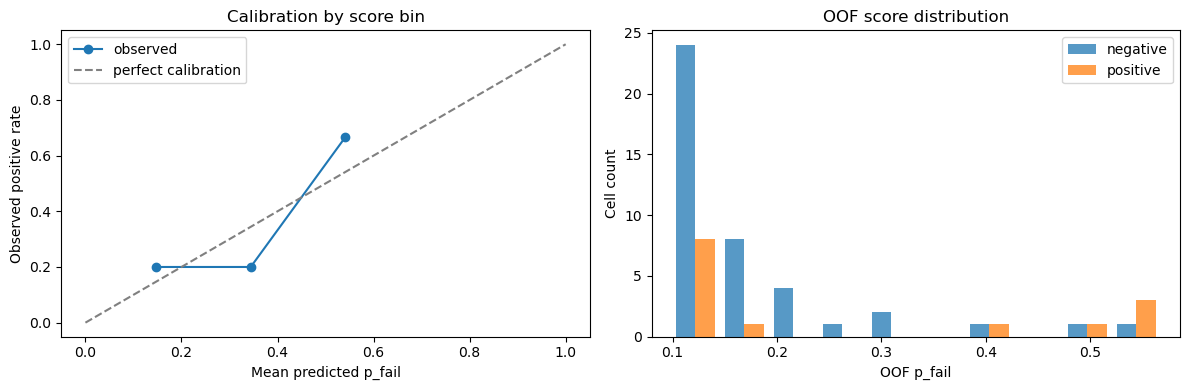

In [4]:
bins = pd.cut(y_score, bins=[0.0, 0.25, 0.50, 0.75, 1.0], include_lowest=True)
calibration = pd.DataFrame({'bin': bins, 'y_true': y_true, 'y_score': y_score}).groupby('bin', observed=True).agg(n=('y_true','size'), mean_predicted=('y_score','mean'), observed_rate=('y_true','mean')).reset_index()
display(calibration)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(calibration['mean_predicted'], calibration['observed_rate'], 'o-', label='observed')
axes[0].plot([0, 1], [0, 1], '--', color='gray', label='perfect calibration')
axes[0].set(xlabel='Mean predicted p_fail', ylabel='Observed positive rate', title='Calibration by score bin'); axes[0].legend()
axes[1].hist([y_score[y_true == 0], y_score[y_true == 1]], bins=10, label=['negative', 'positive'], alpha=0.75)
axes[1].set(xlabel='OOF p_fail', ylabel='Cell count', title='OOF score distribution'); axes[1].legend()
plt.tight_layout()

## 5. Model and feature inventory

**Estimator:** XGBoost gradient-boosted tree classifier. Conservative small-n settings: max_depth=3, n_estimators=50, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, min_child_weight=3, fixed seed 42, single-threaded training. No large hyperparameter grid was used because it would overfit this sample.

In [5]:
display(pd.Series(metadata['xgb_params'], name='value').to_frame())
missing_features = ['plan_curvature', 'profile_curvature', 'dist_to_fault_km', 'lithology_class']
feature_info = pd.DataFrame({'feature': metadata['feature_columns']})
feature_info['status'] = np.where(feature_info['feature'].isin(missing_features), '100% missing this pass', 'used / encoded')
display(feature_info)
print(f"Feature count: {len(feature_info)} | Explicitly missing this pass: {len(missing_features)}")

,value
max_depth,3
n_estimators,50
learning_rate,0.1
subsample,0.8
colsample_bytree,0.8
min_child_weight,3
reg_lambda,1.0
eval_metric,logloss
n_jobs,1


,feature,status
0,elevation_m,used / encoded
1,elevation_min_m,used / encoded
2,elevation_max_m,used / encoded
3,slope_mean_deg,used / encoded
4,slope_max_deg,used / encoded
5,twi_mean,used / encoded
6,relief_m,used / encoded
7,dist_to_road_m,used / encoded
8,plan_curvature,100% missing this pass
9,profile_curvature,100% missing this pass


Feature count: 25 | Explicitly missing this pass: 4


## 6. Important ML and deployment notes

- Training is terrain-only: elevation, slope, TWI, relief, road distance, aspect sin/cos, and one-hot land cover. Verified historical rainfall and soil-moisture time series are not training features yet.
- Four schema columns are native XGBoost missing values and currently contribute no information; retrain after real joins arrive.
- Training and inference share backend/app/risk/features.py, preventing train/serve feature skew.
- Runtime fusion is max(raw_ml_p_fail, capped_rainfall_threshold_exceedance); API/UI p_fail is fused, not raw ML probability.
- SHAP explains the raw ML margin, not the fused score. Runtime confidence is a decisiveness heuristic, not a confidence interval.
- Current integration caveat: live pipeline wiring awaits unification of synthetic and terrain-grid cell ID conventions.

## 7. Reproduce artifacts

From the repository root:

    cd backend
    .venv/Scripts/python.exe -m ml.build_inventory
    .venv/Scripts/python.exe -m ml.train --aoi aizawl
    .venv/Scripts/python.exe -m ml.evaluate --aoi aizawl

The source-of-truth narrative is data/models/eval_report.md; this notebook recalculates the principal metrics from cv_predictions.csv.